# Data Types

### Taxonomy of Visualization Data Types

In information visualization, the process does not begin with visuals or space; it starts with abstract data describing the
world. To help you make sense of this data, you can understand every dataset through three fundamental components:

- Entities — the objects you observe;

- Attributes — the properties describing these objects;

- Structure — the relationships between them.

You might consider an entity to be a person, a document, a country, or a point in space or time. Once the entities are
established, their attributes can then be identified as numerical, categorical, or ordered. You should note that the
structure may or may not be present. However, when it is, it fundamentally changes how you visualize the data.

---

### Attribute Types

Attributes determine how we interpret the data and what we can do with it. There are several types of attributes
to be considered:

- Categorical Attributes
    - Nominal attributes have no inherent order (e.g., color, country).

    - Ordinal attributes are ordered, but the distances between values are not meaningful (e.g., ranking).

- Quantitative attributes use numeric values with meaningful magnitude and distance.

Understanding these distinctions is crucial for working with data. Recognizing and distinguishing these attribute
types is important because they are not just labels—they determine which visual encodings are valid. For
example, this distinction explains why averaging only makes sense for quantitative attributes and not for nominal ones.

---

### Data Structures

Beyond attributes, datasets differ in how entities relate to each other. We distinguish four fundamental structures:

1. Multivariate Data (Tables): Entities are independent. Each is described by attributes. This is possibly the most
   common form of data today due to the rapid development in the field of data science and deep learning.

2. Networks: Entities are connected through arbitrary relationships. Relationships form part of the data structure.

3. Hierarchies (Trees): In a hierarchy, entities are organized in a strict parent–child relation.

4. Text: We consider text as a collection of unstructured entities. For the visualization, we create structured forms,
   such as tables (feature vectors), networks (co-occurrence), or geometric embeddings.

### Foundations of Data-to-Graphic Transformation

Visualization is much more than mapping values to images or animations. Visualization translates both structural relations
in the data and semantics into visual representations.

We must understand the difference between attributes, which refer to the specific properties or characteristics that
encode values, and structure, which determines how data is organized.

This difference is clear when compared to scientific visualization, which usually provides spatial structure. In
information visualization, spatial structure is carefully designed to create a planned layout, making the semantics of
the data interpretable.

### A Guiding Principle

The goal of information visualization is to reveal structure. Everything in this course can be seen as a transformation:
starting with raw data (with its specific attributes, such as variables or fields), then organized into a structured
representation, and finally expressed in a visual form.

### Conceptual Diagram

The following diagram shows a clear structure of the data types that are the fundamentals of Information Visualization.


<img src="./figures/data_type_diagram_white.png" style="margin-right: 10px;" width="500">
<img src="./figures/data_type_diagram.png" style="margin-right: 540px;" width="500">

### Understanding Data in IfoVIS

This abstract example shows how we understand data in InfoVI:

Step 1 — Entities

- Visual Representation: Show dots appearing randomly
- Label: “Entities”

Step 2 — Attributes

- Attach scalars / vectors / strings to each dot
    - categorical: color
    - quantitative: time / position / size / direction

Step 3 — Structure

- scalar, vectors, matrices
- relations: graph
- hierarchical relation: tree
- text

### Illustrative Example

In this example we use the dataset *Les Miserables*. We read the data from a JSON file and show how to move from entities through attributes up 
to the structure. The visualization depends on how we structure the data, in this particular case a graph (network):

- No edges: scatterplot (multivariate)
- Add edges: network
- Constrain edges: tree (hierarchy)


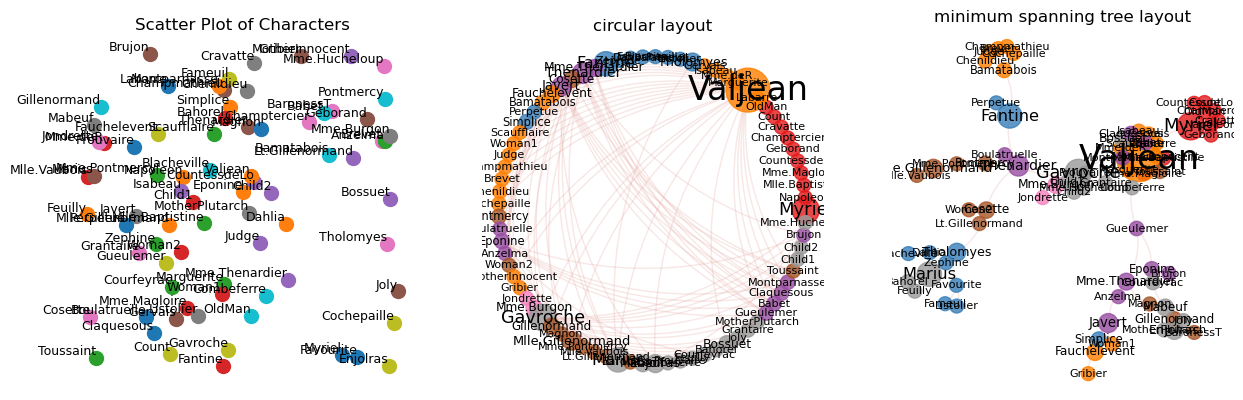

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import networkx as nx

# read the graph data from a JSON file
with open("../../data/lesmiserables.json", "r") as f:
    graph_data = json.load(f)

for character in graph_data["nodes"]:
    character["x"] = np.random.rand()
    character["y"] = np.random.rand()

ncols = 3
v_size = 5
h_size = ncols * v_size
# first plot: scatter plot of characters
fig, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(h_size, v_size))

for character in graph_data["nodes"]:
    axes[0].scatter(character["x"], character["y"], s=100)
    axes[0].text(
        character["x"],
        character["y"],
        character["name"],
        fontsize=9,
        ha="right",
        va="bottom",
    )
axes[0].axis("off")
axes[0].set_aspect("equal")
axes[0].set_title("Scatter Plot of Characters")


# create a graph from the data
graph = nx.node_link_graph(
    graph_data, directed=False, edges="links", nodes="nodes", multigraph=False
)
# compute node centrality: weights for nodes according to importance (betweenness centrality)
dict_b = nx.betweenness_centrality(graph)
# set node size according to centrality
nx.set_node_attributes(graph, dict_b, "betweenness")
# remember min and max centrality for scaling
graph.graph.update({"b_min": min(dict_b.values()), "b_max": max(dict_b.values())})
# compute node communities with louvain method
partition = nx.community.louvain_communities(graph)
# set community as node attribute
for i, community in enumerate(partition):
    for node in community:
        graph.nodes[node]["community"] = i


# helper function to draw nodes with size and color according to attributes
def draw_graph(g, pos, ax, title=""):
    # normalization values
    b_min = g.graph["b_min"]
    b_max = g.graph["b_max"]
    n_min = 100  # node minimum size
    n_max = 1000  # node maximum size
    f_min = 8  # font minimum size
    f_max = 24  # font maximum size

    # first draw edges
    # nx.draw_networkx_edges(graph, pos, alpha=0.5) # simple graph drawing
    for u, v in g.edges():
        arrow = FancyArrowPatch(
            posA=pos[u],
            posB=pos[v],
            arrowstyle="-",
            alpha=0.3,
            color="#e6b0aa",
            connectionstyle="arc3,rad=0.2",
        )
        ax.add_patch(arrow)
    # draw nodes
    nx.draw_networkx_nodes(
        g,
        pos,
        node_size=[
            n_min + (b[1]["betweenness"] - b_min) / (b_max - b_min) * (n_max - n_min)
            for b in g.nodes(data=True)
        ],
        node_color=[c for c in nx.get_node_attributes(g, "community").values()],
        cmap="Set1",
        alpha=0.8,
        ax=ax,
    )
    # add labels
    for n in graph.nodes(data=True):
        nx.draw_networkx_labels(
            graph,
            pos,
            labels={n[0]: n[1]["name"]},
            font_size=f_min
            + (n[1]["betweenness"] - b_min) / (b_max - b_min) * (f_max - f_min),
            ax=ax,
        )

    ax.set_aspect("equal")
    ax.set_title(title)
    p = ax.axis("off")

    return p


# second plot: draw circular layout
pos_circular = nx.circular_layout(graph, scale=0.5, center=(0.5, 0.5))
draw_graph(graph, pos_circular, axes[1], "circular layout")

# third plot: draw minimum spanning tree layout
mst = nx.minimum_spanning_tree(graph, weight="value")
try:
    mst_pos = nx.nx_agraph.graphviz_layout(mst, prog="dot")
except:
    mst_pos = nx.spring_layout(mst)
draw_graph(mst, mst_pos, axes[2], "minimum spanning tree layout")

plt.show()

## Data Types in this Lecture

### Multivariate Data

In Information Visualization, Multivariate Data refers to datasets where each observation (or entity) is characterized by multiple independent and
dependent variables.Unlike univariate (one-variable) or bivariate (two-variable) data, multivariate data allows researchers to identify complex
relationships, clusters, and correlations across multiple dimensions simultaneously.

A dataset containing multivariate data is typically represented as a table where rows are the entities, and columns are the attributes. Mathematically,
a single entity or data point is a vector, where some attributes are quantitative and others are categorical: $𝐱_𝑖=[𝑥_{𝑖,1},\dots,𝑥_{𝑖,𝑛}]$,
for  $𝑛$-dimensional data.

Note: In this chapter we include Geodata (Geospatial data), because geodata is essentially a specialized form of multivariate data. In this context, 
geographic location serves as two or three of the attributes that define the entity. The geometric (spatial) attributes determines the location. 
Thematic attirbutes, categorical or quantitative, define what is that location. 

### Networks (Graphs)

A network, or graph, is a dataset that focuses solely on the relationships between entities, rather than just the entities themselves. When we consider
the data as multivariate data, a table provides information about the entities. In contrast, a network is concerned with how entities are interconnected.

Informally, a network comprises two fundamental components: nodes, which represent individual actors or objects, and edges, which establish connections 
between them. A classic example of a network is a social network, where each person serves as a node, and the relationships between individuals are 
represented as links. 

### Hierarchies (Trees)

When relationships transcend mere “connections” and begin to suggest ownership, inclusion, or rank, you transition from a general network to a Hierarchy
(or Tree). In a hierarchy, connections are directed and specific, establishing a distinct “parent-child” structure. 
Hierarchies can be found in various forms, such as family trees, Russian nesting dolls, organizational charts of enterprises, and even books. In a book,
the root node is the book itself, and it branches out into chapters, paragraphs, sentences, and so on.

### Text

In information visualization, text is often categorized as unstructured data. Unlike tables with fixed columns, text is a dense sequence of symbols that 
necessitates substantial processing before visualization.

The digitization of ancient manuscripts and historical corpora has revolutionized the humanities into a data-driven field, commonly referred to as 
**Digital Humanities**.